# CRC Data Preprocessing: Mapping VisiumHD Annotations to Xenium

This notebook demonstrates how to transfer spatial compartment annotations from VisiumHD to Xenium cells using nearest neighbor matching.

## Overview

1. **VisiumHD** provides tissue-level annotations (Tumor, Interface, Tissue compartments)
2. **Xenium** provides single-cell resolution expression data
3. We transfer annotations by spatially matching each Xenium cell to the nearest VisiumHD spot

## Data Sources

- **VisiumHD**: 10x Human Colon Cancer dataset with pre-computed `Periphery` annotations
- **Xenium**: 10x Xenium CRC dataset (307,762 cells, 541 genes)

---
## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# USER INPUT: Data paths
# =============================================================================
# Xenium cells parquet (from 10x Xenium output)
XENIUM_CELLS_PATH = '/Users/mchen12/spatialLR/crc_data/Xenium_P1CRC/cells.parquet'

# VisiumHD metadata with compartment annotations (Periphery column)
VISIUMHD_META_PATH = '/Users/mchen12/spatialLR/crc_data/HumanColonCancer_VisiumHD/MetaData/P1CRC_Metadata.parquet'

# Output path
OUTPUT_PATH = '/Users/mchen12/spatialLR/crc/xenium_with_compartments.parquet'

---
## 2. Load Data

In [2]:
# Load Xenium cells
print('Loading Xenium cells...')
xenium = pd.read_parquet(XENIUM_CELLS_PATH)
print(f'  Cells: {len(xenium):,}')
print(f'  Columns: {list(xenium.columns)}')
print(f'  X range: {xenium["x_centroid"].min():.1f} - {xenium["x_centroid"].max():.1f} µm')
print(f'  Y range: {xenium["y_centroid"].min():.1f} - {xenium["y_centroid"].max():.1f} µm')

Loading Xenium cells...


  Cells: 307,762
  Columns: ['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area']
  X range: 6.6 - 6653.5 µm
  Y range: 7.4 - 7238.3 µm


In [3]:
# Load VisiumHD metadata with compartment annotations
print('Loading VisiumHD metadata...')
visiumhd_raw = pd.read_parquet(VISIUMHD_META_PATH)
print(f'  Total spots: {len(visiumhd_raw):,}')

# Filter to spots with valid Periphery annotations
# (Some spots may be outside annotated regions)
visiumhd = visiumhd_raw[visiumhd_raw['Periphery'].notna()].copy()
print(f'  Spots with Periphery annotation: {len(visiumhd):,}')

print(f'  X range: {visiumhd["X"].min():.2f} - {visiumhd["X"].max():.2f}')
print(f'  Y range: {visiumhd["Y"].min():.2f} - {visiumhd["Y"].max():.2f}')

# Show compartment distribution
print(f'\nPeriphery (compartment) distribution:')
for comp, n in visiumhd['Periphery'].value_counts().items():
    print(f'  {comp}: {n:,} ({100*n/len(visiumhd):.1f}%)')

Loading VisiumHD metadata...


  Total spots: 702,244
  Spots with Periphery annotation: 507,686
  X range: 4.56 - 206.23
  Y range: -310.67 - -103.99

Periphery (compartment) distribution:
  Tissue: 348,117 (68.6%)
  Tumor: 126,732 (25.0%)
  50 micron: 32,837 (6.5%)


---
## 3. Coordinate Transformation

Xenium and VisiumHD use different coordinate systems:
- **Xenium**: Coordinates in microns (µm)
- **VisiumHD**: Coordinates in a scaled/normalized unit

We need to transform Xenium coordinates to match VisiumHD before spatial matching.

In [4]:
# Compute coordinate transformation parameters
# We align by matching the bounding boxes

# Xenium bounds (source)
xen_x_min, xen_x_max = xenium['x_centroid'].min(), xenium['x_centroid'].max()
xen_y_min, xen_y_max = xenium['y_centroid'].min(), xenium['y_centroid'].max()

# VisiumHD bounds (target)
vhd_x_min, vhd_x_max = visiumhd['X'].min(), visiumhd['X'].max()
vhd_y_min, vhd_y_max = visiumhd['Y'].min(), visiumhd['Y'].max()

# Compute scale factors
scale_x = (vhd_x_max - vhd_x_min) / (xen_x_max - xen_x_min)
scale_y = (vhd_y_max - vhd_y_min) / (xen_y_max - xen_y_min)

print(f'Scale factors:')
print(f'  X: {scale_x:.6f}')
print(f'  Y: {scale_y:.6f}')
print(f'  (Xenium µm × scale = VisiumHD units)')

Scale factors:
  X: 0.030341
  Y: 0.028584
  (Xenium µm × scale = VisiumHD units)


In [5]:
# Transform Xenium coordinates to VisiumHD space
xenium_x_transformed = (xenium['x_centroid'].values - xen_x_min) * scale_x + vhd_x_min
xenium_y_transformed = (xenium['y_centroid'].values - xen_y_min) * scale_y + vhd_y_min

print('Transformed Xenium coordinates:')
print(f'  X range: {xenium_x_transformed.min():.2f} - {xenium_x_transformed.max():.2f}')
print(f'  Y range: {xenium_y_transformed.min():.2f} - {xenium_y_transformed.max():.2f}')
print(f'\nVisiumHD coordinates:')
print(f'  X range: {vhd_x_min:.2f} - {vhd_x_max:.2f}')
print(f'  Y range: {vhd_y_min:.2f} - {vhd_y_max:.2f}')

Transformed Xenium coordinates:
  X range: 4.56 - 206.23
  Y range: -310.67 - -103.99

VisiumHD coordinates:
  X range: 4.56 - 206.23
  Y range: -310.67 - -103.99


---
## 4. Spatial Matching

For each Xenium cell, find the nearest VisiumHD spot and transfer its compartment annotation.

In [6]:
# Build KD-tree from VisiumHD spots
print('Building spatial index for VisiumHD spots...')
visiumhd_coords = visiumhd[['X', 'Y']].values
tree = cKDTree(visiumhd_coords)
print(f'  Indexed {len(visiumhd_coords):,} spots')

Building spatial index for VisiumHD spots...


  Indexed 507,686 spots


In [7]:
# Find nearest VisiumHD spot for each Xenium cell
print('Finding nearest neighbors...')
xenium_coords_transformed = np.column_stack([xenium_x_transformed, xenium_y_transformed])
distances, indices = tree.query(xenium_coords_transformed, k=1)

print(f'  Matched {len(indices):,} cells')
print(f'  Distance stats (in VisiumHD units):')
print(f'    Min: {distances.min():.4f}')
print(f'    Median: {np.median(distances):.4f}')
print(f'    Max: {distances.max():.4f}')

Finding nearest neighbors...


  Matched 307,762 cells
  Distance stats (in VisiumHD units):
    Min: 0.0002
    Median: 0.1023
    Max: 38.6786


In [8]:
# Transfer compartment labels from VisiumHD to Xenium
xenium['compartment'] = visiumhd.iloc[indices]['Periphery'].values
xenium['compartment_distance'] = distances

print('Compartment distribution in Xenium cells:')
for comp, n in xenium['compartment'].value_counts().items():
    print(f'  {comp}: {n:,} ({100*n/len(xenium):.1f}%)')

Compartment distribution in Xenium cells:
  Tissue: 209,870 (68.2%)
  Tumor: 77,497 (25.2%)
  50 micron: 20,395 (6.6%)


---
## 5. Validation

Visualize the transferred annotations to ensure they make spatial sense.

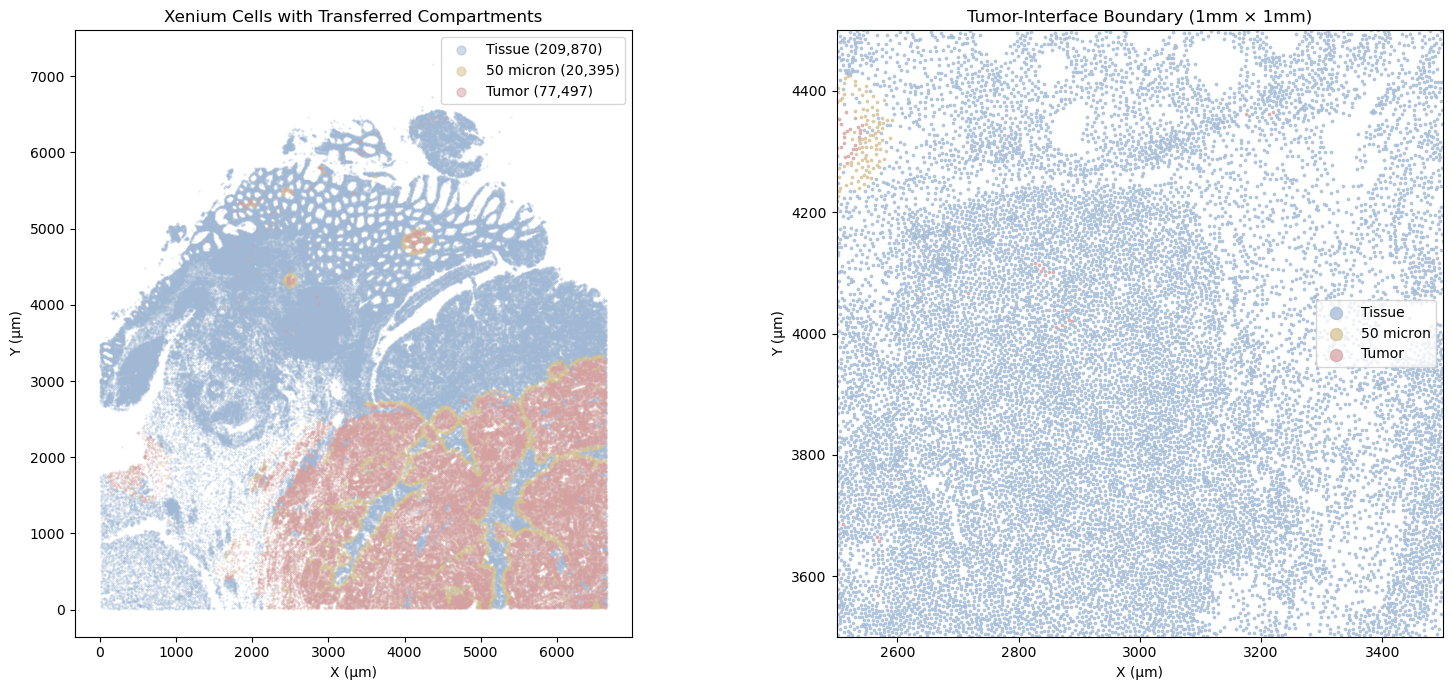

In [9]:
# Plot spatial distribution of compartments
COMP_COLORS = {
    'Tumor': '#E07A5F',
    '50 micron': '#F2CC8F',
    'Tissue': '#3D85C6',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Full tissue
ax = axes[0]
for comp in ['Tissue', '50 micron', 'Tumor']:  # Plot order: back to front
    mask = xenium['compartment'] == comp
    ax.scatter(
        xenium.loc[mask, 'x_centroid'],
        xenium.loc[mask, 'y_centroid'],
        c=COMP_COLORS[comp],
        s=0.1,
        alpha=0.5,
        label=f'{comp} ({mask.sum():,})'
    )
ax.set_aspect('equal')
ax.set_xlabel('X (µm)')
ax.set_ylabel('Y (µm)')
ax.set_title('Xenium Cells with Transferred Compartments')
ax.legend(markerscale=20, loc='upper right')

# Right: Zoomed view of interface
ax = axes[1]
xlim = (2500, 3500)
ylim = (3500, 4500)
for comp in ['Tissue', '50 micron', 'Tumor']:
    mask = (xenium['compartment'] == comp) & \
           (xenium['x_centroid'] > xlim[0]) & (xenium['x_centroid'] < xlim[1]) & \
           (xenium['y_centroid'] > ylim[0]) & (xenium['y_centroid'] < ylim[1])
    ax.scatter(
        xenium.loc[mask, 'x_centroid'],
        xenium.loc[mask, 'y_centroid'],
        c=COMP_COLORS[comp],
        s=3,
        alpha=0.7,
        label=comp
    )
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_aspect('equal')
ax.set_xlabel('X (µm)')
ax.set_ylabel('Y (µm)')
ax.set_title('Tumor-Interface Boundary (1mm × 1mm)')
ax.legend(markerscale=5)

plt.tight_layout()
plt.show()

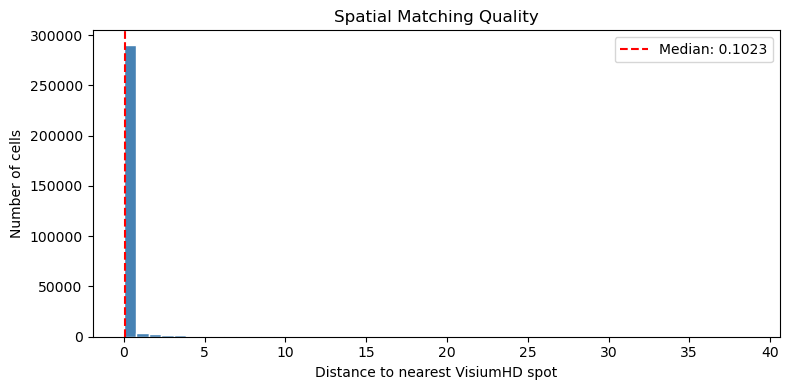

Cells with distance > 99th percentile (9.7204): 3,078


In [10]:
# Check matching distance distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(xenium['compartment_distance'], bins=50, color='#3D85C6', edgecolor='white')
ax.axvline(np.median(distances), color='red', linestyle='--', label=f'Median: {np.median(distances):.4f}')
ax.set_xlabel('Distance to nearest VisiumHD spot')
ax.set_ylabel('Number of cells')
ax.set_title('Spatial Matching Quality')
ax.legend()
plt.tight_layout()
plt.show()

# Flag cells with large matching distances
threshold = np.percentile(distances, 99)
n_uncertain = (distances > threshold).sum()
print(f'Cells with distance > 99th percentile ({threshold:.4f}): {n_uncertain:,}')

---
## 6. Save Results

In [11]:
# Save annotated Xenium data
print(f'Saving to: {OUTPUT_PATH}')
xenium.to_parquet(OUTPUT_PATH, index=False)
print(f'  Saved {len(xenium):,} cells with compartment annotations')
print(f'\nColumns in output:')
print(f'  {list(xenium.columns)}')

Saving to: /Users/mchen12/spatialLR/crc/xenium_with_compartments.parquet
  Saved 307,762 cells with compartment annotations

Columns in output:
  ['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'compartment', 'compartment_distance']


---
## Summary

This notebook demonstrated how to transfer spatial annotations from VisiumHD to Xenium:

1. **Load data**: Xenium cells and VisiumHD metadata with `Periphery` annotations
2. **Coordinate transformation**: Align Xenium (µm) to VisiumHD coordinate space
3. **Spatial matching**: Find nearest VisiumHD spot for each Xenium cell using KD-tree
4. **Transfer labels**: Assign compartment (`Periphery`) from matched VisiumHD spot
5. **Validation**: Visualize to confirm spatial coherence

### Output

The output parquet file contains the original Xenium cell data plus:
- `compartment`: Transferred compartment label (Tumor, 50 micron, Tissue)
- `compartment_distance`: Distance to the matched VisiumHD spot

### Next Steps

Use the annotated data with CONSTELLATION's compartment analysis (see `crc_analysis.ipynb`):
```python
import constellation as cst

meta = pd.read_parquet('data/xenium_with_compartments.parquet')
compartments = meta['compartment'].values
results = cst.run_compartment_analysis(expr_dict, compartments, coords, lr_pairs)
```